<a href="https://colab.research.google.com/github/marcopeduto/marcopeduto/blob/main/Labo_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Libraries import
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

url = 'https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/tips.csv'
data = pd.read_csv(url)
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


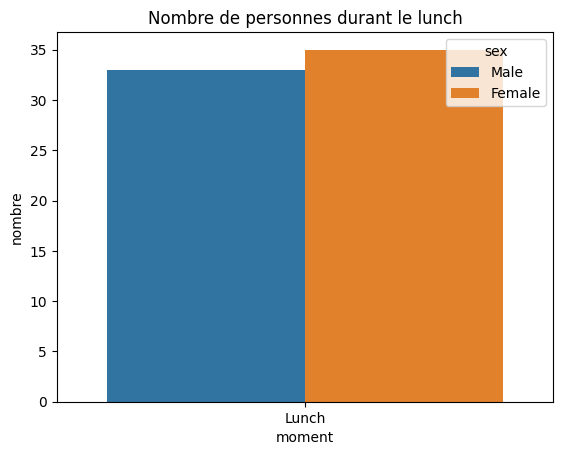

In [ ]:
lunch_customers = data[data['time'] == 'Lunch']
sns.countplot(x='time', hue='sex', data=lunch_customers)

#si on veut que des hommes, on fait comme ça:
#lunch_male_customers = data[(data['time'] == 'Lunch') & (data['sex'] == 'Male')]
#sns.countplot(x='time', data=lunch_male_customers)

plt.title('Nombre de personnes durant le lunch')
plt.xlabel('moment')
plt.ylabel('nombre')
plt.show()

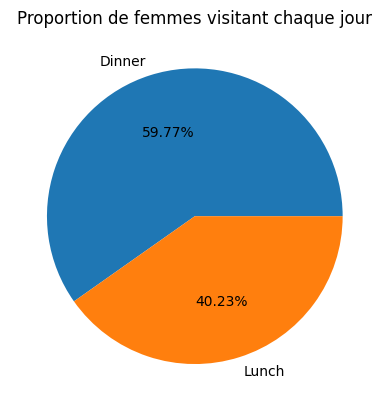

In [ ]:
female_customers = data[data['sex'] == 'Female']
female_count_by_day = female_customers['time'].value_counts()
plt.pie(female_count_by_day, labels=female_count_by_day.index, autopct='%.2f%%')

plt.title('Proportion de femmes visitant chaque jour')
plt.show()

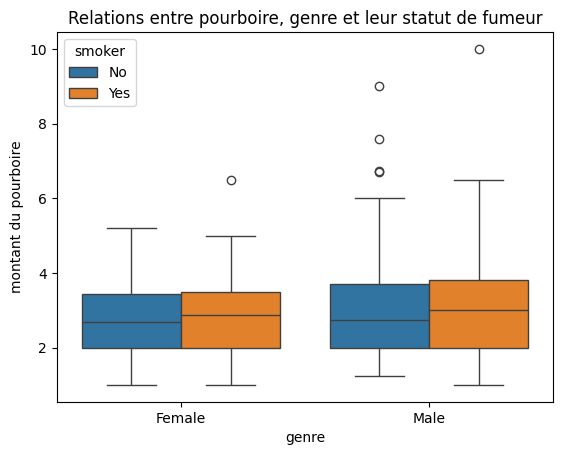

In [ ]:
sns.boxplot(x='sex', y='tip', hue='smoker', data=data)

plt.title('Relations entre pourboire, genre et leur statut de fumeur')
plt.xlabel('genre')
plt.ylabel('montant du pourboire')
plt.show()

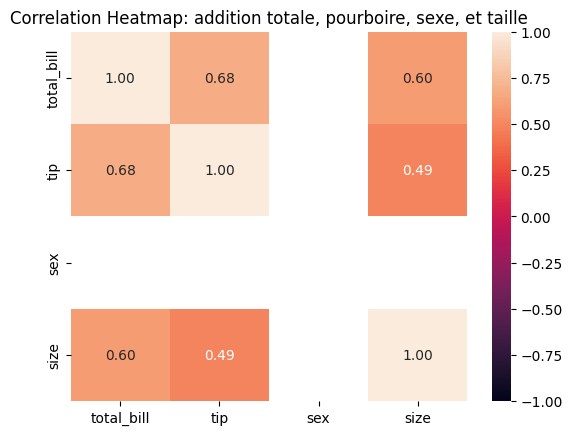

In [ ]:
data['sex'] = data['sex'].map({'Female': 1, 'Male': 0})

correlation_data = data[['total_bill', 'tip', 'sex', 'size']]
correlation_matrix = correlation_data.corr()
sns.heatmap(correlation_matrix, fmt='.2f', annot=True, cbar=True, vmin=-1, vmax=1)

plt.title('Correlation Heatmap: addition totale, pourboire, sexe, et taille')
plt.show()

In [ ]:
avg_tip_data = data.groupby(['sex', 'day', 'time', 'smoker'])['tip'].mean().reset_index()
fig = px.treemap(avg_tip_data, path=['sex', 'day', 'time'], values='tip', color='tip',
                 hover_data=['smoker'], color_continuous_scale='Viridis', title='Average Tip by Gender, Smoking Status, Day, and Time')
fig.show()

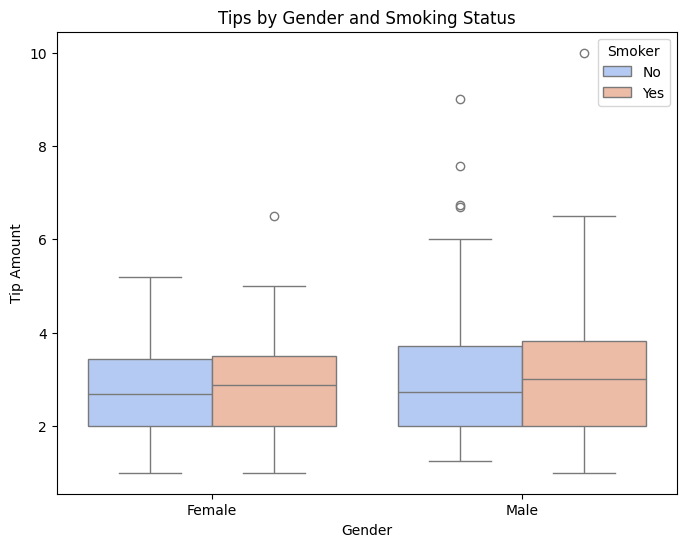

In [ ]:
#question 1 moodle
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='tip', hue='smoker', data=data, palette='coolwarm')
plt.xlabel('Gender')
plt.ylabel('Tip Amount')
plt.title('Tips by Gender and Smoking Status')
plt.legend(title='Smoker')
plt.show()

In [ ]:
avg_tips = data.groupby(['sex', 'day', 'time'])['tip'].mean().reset_index()

# Création de la Treemap
fig = px.treemap(
    avg_tips,
    path=['sex', 'day', 'time'],  # Hiérarchie : Sexe → Jour → Moment du repas
    values='tip',  # Taille des blocs = montant moyen du pourboire
    color='tip',  # Couleur basée sur le montant du pourboire
    color_continuous_scale='Blues',
    title="Treemap des Pourboires Moyens par Sexe, Jour et Moment du Repas"
)

# Afficher la Treemap
fig.show()

# Afficher les résultats de la proposition B sur moodle
total_tips_by_sex = data.groupby('sex')['tip'].sum()
print(total_tips_by_sex)

sex
Female    246.51
Male      485.07
Name: tip, dtype: float64


In [ ]:
import pandas as pd
import plotly.express as px

# Chargement du dataset
url = 'https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/tips.csv'
data_tips = pd.read_csv(url)

# Calcul du montant moyen des pourboires par sexe, jour et moment du repas
avg_tips = data_tips.groupby(['sex', 'day', 'time'])['tip'].mean().reset_index()

# Création de la Treemap
fig = px.treemap(avg_tips,
                 path=['sex', 'day', 'time'],
                 values='tip',
                 title='Montant moyen des pourboires par genre, jour et moment du repas',
                 color='tip',
                 color_continuous_scale='Blues')

# Affichage de la Treemap
fig.show()